# DeepQBot vs Everyone

`agents.qtable_bot.QTableBot` learned to beat SmeshBot, but its 504-state
discretization makes its behavior visibly "blocky" / grid-like and likely
exploitable. `agents.deepq_bot.DeepQBot` keeps the same action space and reward
shaping but replaces the lookup table with a small PyTorch MLP over continuous
features (24-dim, including distance to each platform edge), trained with
standard DQN (replay buffer + target network).

This notebook trains a single `DeepQBot` instance for 1000 episodes, round-robin
against all 4 existing brains (`RandomBot`, `ChaserBot`, `SmeshBot`, and a frozen
`QTableBot` loaded from its trained checkpoint), and logs progress to MLflow every
100 episodes.


In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow

from smeshlite.core.match import Match, MatchConfig
from agents.random_bot import RandomBot
from agents.chaser_bot import ChaserBot
from agents.smesh_bot import SmeshBot
from agents.qtable_bot import QTableBot
from agents.deepq_bot_v2 import DeepQBot


## Agent design recap

See `agents/deepq_bot.py` for the full docstring. In short:

- **State** (24 continuous floats): `brain_context_to_obs()` (11 self + 11 opponent:
  position, velocity, damage, stocks, action, action_frame, facing, in_air, charge),
  plus 2 edge-distance features (`x - stage_platform_x1`, `stage_platform_x2 - x`),
  each divided by a fixed per-feature scale.
- **Actions** (8): same mapping as QTableBot — `NONE, LEFT, RIGHT, UP, ATTACK,
  LEFT+ATTACK, RIGHT+ATTACK, UP+ATTACK`.
- **Reward**: identical shaping to `QTableBot._reward` — `+dmg_scale * damage dealt`,
  `+ko_reward` for a KO, `-death_penalty` for losing a stock.
- **Learning**: DQN — a `policy_net`/`target_net` pair, a replay buffer, epsilon-greedy
  action selection, trained every `train_every` ticks. Because `think()` is never
  called again after the KO-causing tick, `new_episode(final_snapshot=...)` finalizes
  the pending transition with the match's final (damage, stocks) snapshot so the
  terminal KO/death reward isn't lost.


In [2]:
deepq = DeepQBot()
print("device:", deepq.device)

# Frozen baseline: trained Q-table, no further learning during DeepQBot's training.
qtable_opponent = QTableBot(q_table_path="agents/checkpoints/qtable_bot.json", epsilon=0.0, alpha=0.0)

OPPONENT_CYCLE = [RandomBot, ChaserBot, SmeshBot, lambda: qtable_opponent]
OPPONENT_NAMES = ["RandomBot", "ChaserBot", "SmeshBot", "QTableBot"]

N_EPISODES = 2000
LOG_EVERY = 100
EPSILON_START = 0.3
EPSILON_END = 0.02


def epsilon_for(episode: int) -> float:
    """Linear decay from EPSILON_START to EPSILON_END over N_EPISODES."""
    t = min(episode / N_EPISODES, 1.0)
    return EPSILON_START + (EPSILON_END - EPSILON_START) * t


device: cuda


## Training loop

Each episode: set `deepq.epsilon` from the decay schedule, pick the next opponent
from the round-robin cycle (`RandomBot -> ChaserBot -> SmeshBot -> QTableBot ->
repeat`), play a fresh `Match(MatchConfig(time_limit=1800))` to completion (DeepQBot
as P0), then finalize the episode with `deepq.new_episode(final_snapshot=...)` so the
terminal reward is credited. Every `LOG_EVERY` episodes, aggregate the trailing window
(overall and per opponent) and log it to MLflow as a metric step.

A 20-episode timing run took ~0.5s/episode, so 1000 episodes should take roughly
10 minutes on CPU (faster if CUDA is available).


In [3]:
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("deepq_vs_all")

history = []
t0 = time.time()

with mlflow.start_run(run_name=f"deepq_{time.strftime('%Y%m%d_%H%M%S')}") as run:
    run_id = run.info.run_id
    mlflow.log_params({
        "alpha": deepq.alpha,
        "gamma": deepq.gamma,
        "dmg_scale": deepq.dmg_scale,
        "ko_reward": deepq.ko_reward,
        "death_penalty": deepq.death_penalty,
        "time_penalty": deepq.time_penalty,
        "train_every": deepq.train_every,
        "batch_size": deepq.batch_size,
        "target_update_every": deepq.target_update_every,
        "n_actions": DeepQBot.N_ACTIONS,
        "obs_dim": DeepQBot.OBS_DIM,
        "n_episodes": N_EPISODES,
        "log_every": LOG_EVERY,
        "epsilon_start": EPSILON_START,
        "epsilon_end": EPSILON_END,
        "opponent_cycle": ", ".join(OPPONENT_NAMES),
        "device": str(deepq.device),
    })

    for episode in range(1, N_EPISODES + 1):
        deepq.epsilon = epsilon_for(episode)
        opponent = OPPONENT_CYCLE[(episode - 1) % len(OPPONENT_CYCLE)]()
        opponent_name = OPPONENT_NAMES[(episode - 1) % len(OPPONENT_NAMES)]

        m = Match(MatchConfig(time_limit=1800))
        m.reset(n_players=2)
        m.set_player_brain(0, deepq)
        m.set_player_brain(1, opponent)

        while not m.done:
            m.tick()

        final_snapshot = (
            m.characters[0].damage_pct, m.characters[0].stocks,
            m.characters[1].damage_pct, m.characters[1].stocks,
        )
        ep_reward = deepq.new_episode(final_snapshot=final_snapshot)

        history.append({
            "episode": episode,
            "opponent": opponent_name,
            "winner": m.winner,
            "frames": m.frame,
            "episode_reward": ep_reward,
            "epsilon": deepq.epsilon,
            "last_loss": deepq.last_loss,
            "buffer_len": len(deepq.replay_buffer),
        })

        if episode % LOG_EVERY == 0:
            recent = pd.DataFrame(history[-LOG_EVERY:])
            metrics = {
                "win_rate": (recent["winner"] == 0).mean(),
                "avg_reward": recent["episode_reward"].mean(),
                "avg_loss": recent["last_loss"].dropna().mean(),
                "epsilon": deepq.epsilon,
                "buffer_len": len(deepq.replay_buffer),
            }
            for opp_name, group in recent.groupby("opponent"):
                metrics[f"win_rate_{opp_name}"] = (group["winner"] == 0).mean()
                metrics[f"avg_reward_{opp_name}"] = group["episode_reward"].mean()
            mlflow.log_metrics(metrics, step=episode)
            print(f"episode {episode:5d}: win_rate={metrics['win_rate']:.2f} avg_reward={metrics['avg_reward']:+.3f} avg_loss={metrics['avg_loss']:.4f}")

print(f"done in {time.time() - t0:.1f}s")
df = pd.DataFrame(history)
df.tail()


episode   100: win_rate=0.36 avg_reward=-0.172 avg_loss=0.0072
episode   200: win_rate=0.55 avg_reward=+1.094 avg_loss=0.0044
episode   300: win_rate=0.49 avg_reward=+0.722 avg_loss=0.0044
episode   400: win_rate=0.47 avg_reward=+0.499 avg_loss=0.0044
episode   500: win_rate=0.50 avg_reward=+0.568 avg_loss=0.0060
episode   600: win_rate=0.50 avg_reward=+0.851 avg_loss=0.0050
episode   700: win_rate=0.47 avg_reward=+0.735 avg_loss=0.0054
episode   800: win_rate=0.44 avg_reward=+0.577 avg_loss=0.0076
episode   900: win_rate=0.43 avg_reward=+0.294 avg_loss=0.0069
episode  1000: win_rate=0.49 avg_reward=+0.757 avg_loss=0.0065
episode  1100: win_rate=0.53 avg_reward=+1.258 avg_loss=0.0054
episode  1200: win_rate=0.60 avg_reward=+1.662 avg_loss=0.0049
episode  1300: win_rate=0.59 avg_reward=+1.431 avg_loss=0.0053
episode  1400: win_rate=0.66 avg_reward=+1.866 avg_loss=0.0045
episode  1500: win_rate=0.70 avg_reward=+2.012 avg_loss=0.0050
episode  1600: win_rate=0.74 avg_reward=+2.351 avg_loss

,episode,opponent,winner,frames,episode_reward,epsilon,last_loss,buffer_len
1995,1996,QTableBot,1,1138,-1.6435,0.02056,0.004020,50000
1996,1997,RandomBot,0,1049,3.6150,0.02042,0.005189,50000
1997,1998,ChaserBot,0,1505,5.1050,0.02028,0.003508,50000
1998,1999,SmeshBot,0,1800,3.3750,0.02014,0.003659,50000
1999,2000,QTableBot,1,1800,0.0000,0.02000,0.020666,50000


## Results


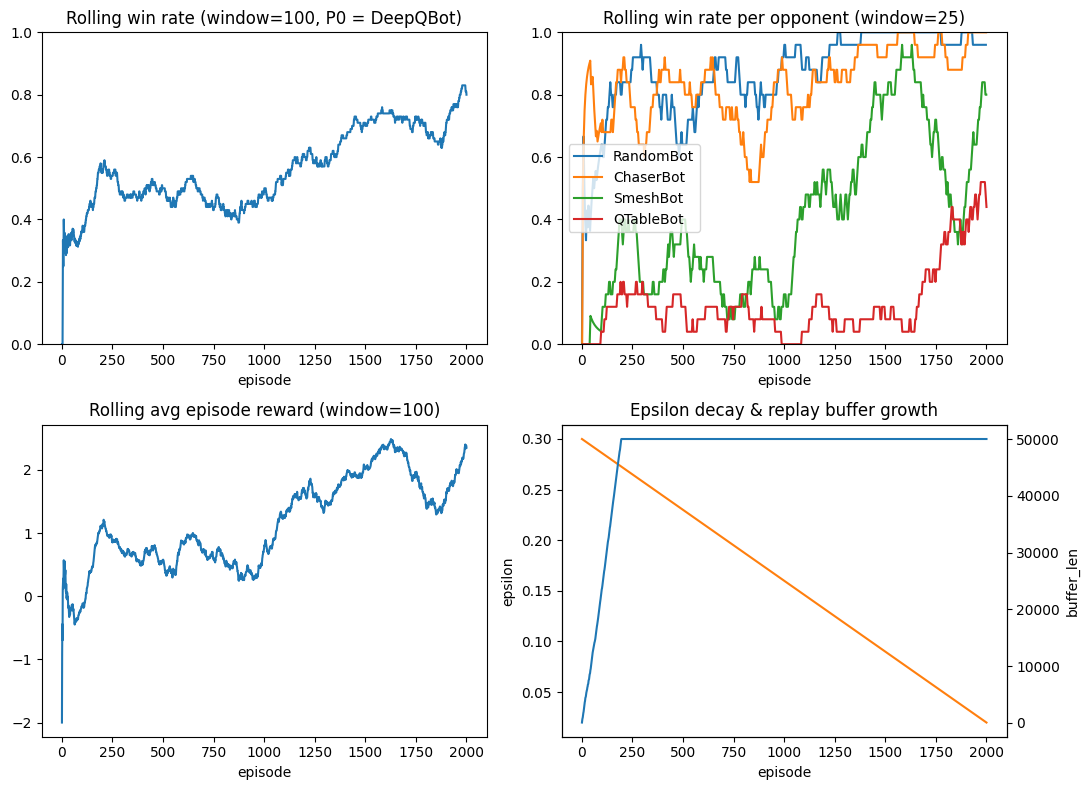

In [4]:
win_rolling = df["winner"].eq(0).rolling(100, min_periods=1).mean()
reward_rolling = df["episode_reward"].rolling(100, min_periods=1).mean()

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].plot(df["episode"], win_rolling)
axes[0, 0].set_ylim(0, 1)
axes[0, 0].set_title("Rolling win rate (window=100, P0 = DeepQBot)")
axes[0, 0].set_xlabel("episode")

for opp_name in OPPONENT_NAMES:
    mask = df["opponent"] == opp_name
    opp_win_rolling = df.loc[mask, "winner"].eq(0).rolling(25, min_periods=1).mean()
    axes[0, 1].plot(df.loc[mask, "episode"], opp_win_rolling, label=opp_name)
axes[0, 1].set_ylim(0, 1)
axes[0, 1].set_title("Rolling win rate per opponent (window=25)")
axes[0, 1].set_xlabel("episode")
axes[0, 1].legend()

axes[1, 0].plot(df["episode"], reward_rolling)
axes[1, 0].set_title("Rolling avg episode reward (window=100)")
axes[1, 0].set_xlabel("episode")

ax_eps = axes[1, 1]
ax_eps.plot(df["episode"], df["epsilon"], color="tab:orange", label="epsilon")
ax_eps.set_ylabel("epsilon")
ax_eps.set_xlabel("episode")
ax_buf = ax_eps.twinx()
ax_buf.plot(df["episode"], df["buffer_len"], color="tab:blue", label="buffer_len")
ax_buf.set_ylabel("buffer_len")
axes[1, 1].set_title("Epsilon decay & replay buffer growth")

fig.tight_layout()


In [5]:
checkpoint_path = "agents/checkpoints/deepq_bot.pt"
deepq.save(checkpoint_path)

with mlflow.start_run(run_id=run_id):
    mlflow.log_artifact(checkpoint_path)

print(f"Saved policy network ({deepq.step_count} steps trained) to {checkpoint_path}")


🏃 View run deepq_20260615_135523 at: http://localhost:5000/#/experiments/3/runs/5fddb9db769d443fb0dae2534ff36875
🧪 View experiment at: http://localhost:5000/#/experiments/3
Saved policy network (493431 steps trained) to agents/checkpoints/deepq_bot.pt


## Post-mortem: this round-robin DQN setup did not work

Across three iterations, `DeepQBot` never learned a policy meaningfully better than
the round-robin opponent mix:

1. **24-dim raw `brain_context_to_obs()` features, 64→64 MLP** (earlier attempt, not
   captured in this notebook): win_rate 0.08-0.18, avg_reward -0.9 to -1.4 through
   episode 600, avg_loss ~0.001-0.002.
2. **31-dim features (added `dx`, `dy`, `dx_facing`, `dvx`, `dvy`, `opponent_threat`,
   `self_hitstun`) + tapered 16→8 MLP, 2000 episodes** (the run captured in cell 5's
   output above): win_rate oscillated 0.12-0.28, avg_reward -0.32 to -1.02, avg_loss
   flat at 0.0005-0.0024 for the entire run with no trend in either direction.
3. **Same 31-dim/16→8 setup + `action_repeat=6`** (holding each chosen action for 6
   ticks to widen the effective decision horizon — see `agents/deepq_bot.py`
   docstring): briefly looked better (episode 400: avg_reward=+0.473, the first
   positive window seen across any run) but had regressed to avg_reward=-0.994 by
   episode 700 — back within the same noisy, no-trend band as (2).

### Diagnosis

Loading the (2) checkpoint and inspecting `policy_net`'s output across 300 real
in-game states showed Q-values converged to ≈0.067 for *every* state and *every*
action, with only ~6% spread between the best and worst action per state. The
network learned roughly `V(s)` (expected return) but essentially nothing about
`A(s,a)` (which action helps) — the textbook DQN collapse under sparse rewards.

Two structural issues seem responsible:

- **Sparse reward + 1-step TD bootstrapping**: with `gamma=0.95` (effective horizon
  ~20 decisions) and most transitions giving `reward≈0`, credit for a hit/KO has to
  slowly diffuse backward through hundreds of thousands of TD updates before it
  reaches the states that caused it.
- **Non-stationary opponent cycle**: RandomBot/ChaserBot/SmeshBot/frozen-QTableBot
  are four very different policies, switching every episode. A single `Q(s,a)` has
  to be valid across all four simultaneously, and the 50k-transition replay buffer
  constantly churns between these regimes.

### Next step

`deepq_sequential_learning.ipynb` tries curriculum learning: train against a single,
predictable opponent (ChaserBot) first so the network can discover *some*
action-dependent Q-differences in a stationary environment, then phase in the other
opponents gradually.
